<a href="https://colab.research.google.com/github/thaynaracarvalho/Redes_neurais_Pneumonia-/blob/main/RedesNeurais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
# Configurações iniciais
data_dir = "archive/chest_xray"
default_batch_size = 32
image_size = (224, 224)
default_epochs = 15

In [ ]:
print("Diretório atual:", os.getcwd())

Diretório atual: /content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_dir = "/content/drive/My Drive/archive/chest_xray"

train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

print("Treino existe:", os.path.exists(train_dir))
print("Validação existe:", os.path.exists(val_dir))
print("Teste existe:", os.path.exists(test_dir))

Treino existe: True
Validação existe: True
Teste existe: True


In [ ]:
# Pré-processamento de dados
def preprocess_data():
    train_dir = os.path.join(data_dir, "train")
    val_dir = os.path.join(data_dir, "val")
    test_dir = os.path.join(data_dir, "test")

 # Data Augmentation para o conjunto de treinamento
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )

    val_test_datagen = ImageDataGenerator(rescale=1./255)

    train_data = train_datagen.flow_from_directory(
        train_dir,
        target_size=image_size,
        batch_size=default_batch_size,
        class_mode='binary'
    )

    val_data = val_test_datagen.flow_from_directory(
        val_dir,
        target_size=image_size,
        batch_size=default_batch_size,
        class_mode='binary'
    )

    test_data = val_test_datagen.flow_from_directory(
        test_dir,
        target_size=image_size,
        batch_size=default_batch_size,
        class_mode='binary',
        shuffle=False
    )

    return train_data, val_data, test_data

In [ ]:
# Modelo AlexNet
def build_alexnet(input_shape):
    model = Sequential([
        Conv2D(96, (11, 11), strides=4, activation='relu', input_shape=input_shape),
        MaxPooling2D((3, 3), strides=2),
        Conv2D(256, (5, 5), padding="same", activation="relu"),
        MaxPooling2D((3, 3), strides=2),
        Conv2D(384, (3, 3), padding="same", activation="relu"),
        Conv2D(384, (3, 3), padding="same", activation="relu"),
        Conv2D(256, (3, 3), padding="same", activation="relu"),
        MaxPooling2D((3, 3), strides=2),
        Flatten(),
        Dense(4096, activation="relu"),
        Dropout(0.5),
        Dense(4096, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])
    return model

In [ ]:
# Modelo InceptionV3
def build_inceptionv3(input_shape):
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    x = Flatten()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base_model.input, outputs=output)
    return model

In [ ]:
# Plotagem da matriz de confusão
def plot_confusion_matrix(cm, classes, model_name):

    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"{model_name} - Matriz de Confusão")
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    plt.ylabel('Rótulo Verdadeiro')
    plt.xlabel('Rótulo Predito')

    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, f"{cm[i, j]}", horizontalalignment="center", color="white" if cm[i, j] > cm.max() / 2. else "black")

    plt.tight_layout()
    plt.show()

In [ ]:
def train_and_evaluate_model(model, train_data, val_data, test_data, model_name, epochs=default_epochs):
    callbacks = [
        ModelCheckpoint(f"{model_name}_best_model.keras", save_best_only=True, monitor='val_loss', mode='min'),
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]

    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(train_data,
                        validation_data=val_data,
                        epochs=epochs,
                        callbacks=callbacks,
                        verbose=1)

    # Avaliação no conjunto de teste
    y_true = test_data.classes
    y_pred = (model.predict(test_data) > 0.5).astype(int).flatten()

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    return model, history, acc, precision, recall, f1, cm


In [ ]:
# Plotagem da história de treinamento
def plot_training_history(history, model_name):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Treinamento')
    plt.plot(history.history['val_loss'], label='Validação')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Treinamento')
    plt.plot(history.history['val_accuracy'], label='Validação')
    plt.title(f'{model_name} - Acurácia')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend()

    plt.tight_layout()
    plt.show()

Found 5222 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 1366s 8s/step - accuracy: 0.7508 - loss: 0.5566 - val_accuracy: 0.6250 - val_loss: 0.9670
Epoch 2/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 914s 6s/step - accuracy: 0.9057 - loss: 0.2224 - val_accuracy: 0.6250 - val_loss: 1.0738
Epoch 3/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 930s 6s/step - accuracy: 0.9303 - loss: 0.1837 - val_accuracy: 0.6250 - val_loss: 0.9763
Epoch 4/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 916s 6s/step - accuracy: 0.9334 - loss: 0.1668 - val_accuracy: 0.6250 - val_loss: 2.0054
20/20 ━━━━━━━━━━━━━━━━━━━━ 165s 8s/step


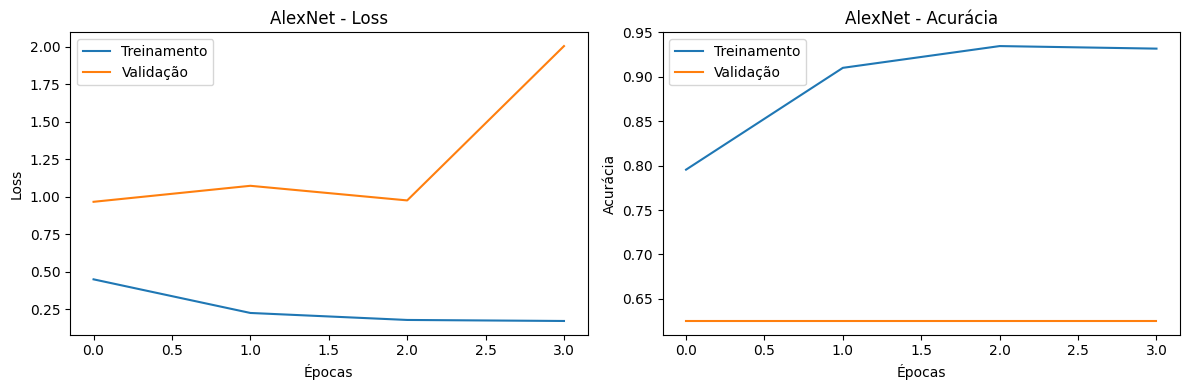

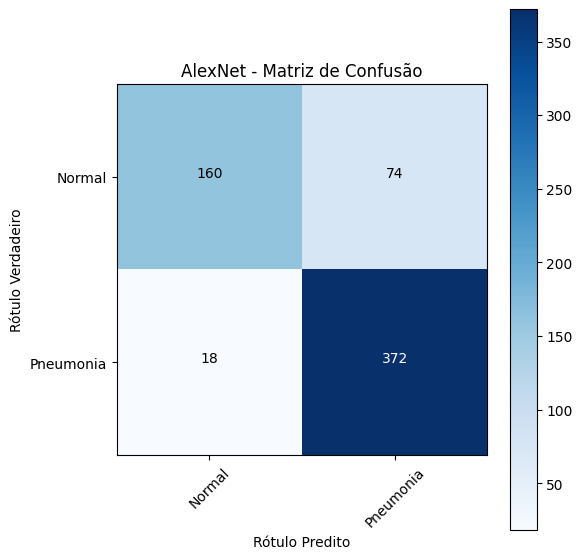

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 2786s 17s/step - accuracy: 0.8760 - loss: 0.3884 - val_accuracy: 0.5625 - val_loss: 1.3804
Epoch 2/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 2711s 17s/step - accuracy: 0.9703 - loss: 0.0855 - val_accuracy: 0.9375 - val_loss: 0.1544
Epoch 3/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 2656s 16s/step - accuracy: 0.9791 - loss: 0.0591 - val_accuracy: 0.6250 - val_loss: 1.0040
Epoch 4/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 2670s 16s/step - accuracy: 0.9808 - loss: 0.0535 - val_accuracy: 0.9375 - val_loss: 0.3962
Epoch 5/15
164/164 ━━━━━━━━━━━━━━━━━━━━ 2643s 16s/step - accuracy: 0.9872 - loss: 0.0328 - val_accuracy: 0.6250 - val_loss: 2.8770
20/20 ━━━━━━━━━━━━━━━━━━━━ 93s 4s/step


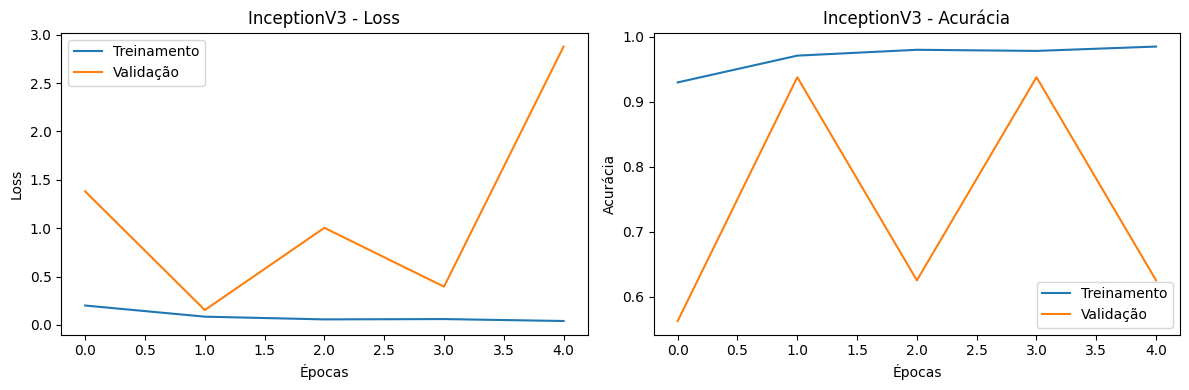

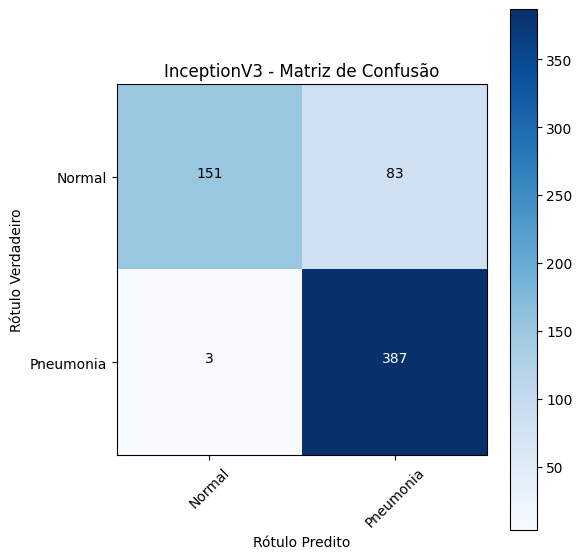


Resumo da Comparação:
Modelo         Acurácia  Precisão  Recall    F1-Score  
AlexNet        0.85      0.83      0.95      0.89      
InceptionV3    0.86      0.82      0.99      0.90      


In [ ]:
 #Função principal
def main():
    train_data, val_data, test_data = preprocess_data()
    input_shape = (image_size[0], image_size[1], 3)

    # Treinar AlexNet
    alexnet_model = build_alexnet(input_shape)
    alexnet_model, alexnet_history, alexnet_acc, alexnet_precision, alexnet_recall, alexnet_f1, alexnet_cm = train_and_evaluate_model(
        alexnet_model, train_data, val_data, test_data, "AlexNet")

    plot_training_history(alexnet_history, "AlexNet")
    plot_confusion_matrix(alexnet_cm, classes=['Normal', 'Pneumonia'], model_name="AlexNet")

    # Treinar InceptionV3
    inception_model = build_inceptionv3(input_shape)
    inception_model, inception_history, inception_acc, inception_precision, inception_recall, inception_f1, inception_cm = train_and_evaluate_model(
        inception_model, train_data, val_data, test_data, "InceptionV3")

    plot_training_history(inception_history, "InceptionV3")
    plot_confusion_matrix(inception_cm, classes=['Normal', 'Pneumonia'], model_name="InceptionV3")

    # Comparação final
    print("\nResumo da Comparação:")
    print(f"{'Modelo':<15}{'Acurácia':<10}{'Precisão':<10}{'Recall':<10}{'F1-Score':<10}")
    print(f"{'AlexNet':<15}{alexnet_acc:<10.2f}{alexnet_precision:<10.2f}{alexnet_recall:<10.2f}{alexnet_f1:<10.2f}")
    print(f"{'InceptionV3':<15}{inception_acc:<10.2f}{inception_precision:<10.2f}{inception_recall:<10.2f}{inception_f1:<10.2f}")

# Executa o programa
if __name__ == "__main__":
    main()